# Antispoofing

In this homework, you will develop a countermeasure against deepfakes and then try to explain it using various XAI techniques.

More specifically, you will implement and train a Countermeasure (CM) system on the Logical Access partition of the [ASVSpoof 2019 Dataset](https://datashare.ed.ac.uk/handle/10283/3336) ([Kaggle Link](https://www.kaggle.com/datasets/awsaf49/asvpoof-2019-dataset)). You may find the [ASVspoof 2019 evaluation plan](https://www.asvspoof.org/asvspoof2019/asvspoof2019_evaluation_plan.pdf) useful.

For the CM, we choose [LightCNN (LCCN)](https://arxiv.org/abs/1511.02683) that once achieved the top place in the competition. We will follow the Speech Technology Center (STC) [paper](https://arxiv.org/abs/1904.05576).

**Hints**:

1. Use STFT (FFT in the paper) as front-end.

2. The dropout layer is put before the last batch norm.

## Dataset [0.5 pts]

We want to train a neural network to predict if the input audio is real or fake. To do so, we need a dataset first. In this homework, we will work with [ASVspoof19](https://arxiv.org/pdf/1911.01601.pdf).

Create a `Dataset` class that downloads the dataset, parses its metadata and, given index $i$, returns $i$-th object of the dataset. Do not forget to preprocess audio for LCNN (calculate stft, etc.).

In [5]:
!curl -L -o asvpoof-2019-dataset.zip\
  https://www.kaggle.com/api/v1/datasets/download/awsaf49/asvpoof-2019-dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 23.5G  100 23.5G    0     0   126M      0  0:03:10  0:03:10 --:--:-- 68.3M


In [6]:
!unzip -q ./asvpoof-2019-dataset.zip

In [8]:
# Переносим всё содержимое из глубокой папки во внутренний корень датасета
!mv /content/LA/LA/* /content/LA/
# Удаляем теперь уже пустую вложенную папку LA
!rmdir /content/LA/LA


In [31]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
import torchaudio

class ASVspoof19Dataset(Dataset):
    def __init__(self, root_dir: str, partition: str = 'train', max_len: int = 400):
        self.root_dir = root_dir
        self.partition = partition
        self.max_len = max_len

        self.dataset_dir = os.path.join(root_dir, "LA")
        self.audio_dir = os.path.join(self.dataset_dir, f"ASVspoof2019_LA_{partition}", "flac")

        if partition == 'train':
            protocol_name = "ASVspoof2019.LA.cm.train.trn.txt"
        elif partition == 'dev':
            protocol_name = "ASVspoof2019.LA.cm.dev.trl.txt"
        else:
            protocol_name = f"ASVspoof2019.LA.cm.{partition}.txt"

        protocol_file = os.path.join(self.dataset_dir, "ASVspoof2019_LA_cm_protocols", protocol_name)

        if not os.path.exists(protocol_file):
            alt_protocol_file = os.path.join(self.dataset_dir, "ASVspoof2019_LA_cm_protocols", f"ASVspoof2019.LA.cm.{partition}.txt")
            if os.path.exists(alt_protocol_file):
                protocol_file = alt_protocol_file
            else:
                raise FileNotFoundError(f"Файл протокола не найден!")

        self.data_list = self._parse_protocol(protocol_file)

    def _parse_protocol(self, protocol_path: str) -> list:
        data_list = []
        with open(protocol_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 4:
                    continue
                audio_id = parts[1]

                # Проверяем оба варианта написания для универсальности
                label = 1 if 'bonafide' in parts or 'bona_fide' in parts else 0

                audio_path = os.path.join(self.audio_dir, f"{audio_id}.flac")
                data_list.append((audio_path, label))
        return data_list

    def _preprocess_audio(self, audio_path: str) -> torch.Tensor:
        waveform, sample_rate = torchaudio.load(audio_path)

        n_fft = 512
        win_length = 320
        hop_length = 160

        stft_complex = torch.stft(
            waveform,
            n_fft=n_fft,
            hop_length=hop_length,
            win_length=win_length,
            window=torch.hamming_window(win_length).to(waveform.device),
            return_complex=True
        )

        spectrogram = torch.abs(stft_complex)
        spectrogram = spectrogram.squeeze(0)
        spectrogram = torch.log(spectrogram + 1e-9)

        time_steps = spectrogram.shape[1]
        if time_steps < self.max_len:
            pad_amount = self.max_len - time_steps
            spectrogram = torch.nn.functional.pad(spectrogram, (0, pad_amount), "constant", -9)
        else:
            spectrogram = spectrogram[:, :self.max_len]

        spectrogram = spectrogram.unsqueeze(0)
        return spectrogram

    def __len__(self) -> int:
        return len(self.data_list)

    def __getitem__(self, idx: int):
        audio_path, label = self.data_list[idx]
        try:
            feature = self._preprocess_audio(audio_path)
        except Exception as e:
            feature = torch.zeros((1, 257, self.max_len))
        return feature, torch.tensor(label, dtype=torch.long)


**Hint**: when working in Kaggle, it is easier and faster to use dataset as kaggle input. We can use it directly or add a symlink to a local dir using `ln -s`.
**Hint**: it might be easier to do this homework in Kaggle, since model training may take some time

Create train/eval dataset and dataloaders:

In [32]:
train_dataset = ASVspoof19Dataset(root_dir=ROOT_DIR, partition='train', max_len=MAX_LEN)
dev_dataset = ASVspoof19Dataset(root_dir=ROOT_DIR, partition='dev', max_len=MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
dev_loader = DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, drop_last=False)

Visualize one object, just to check that all is fine:

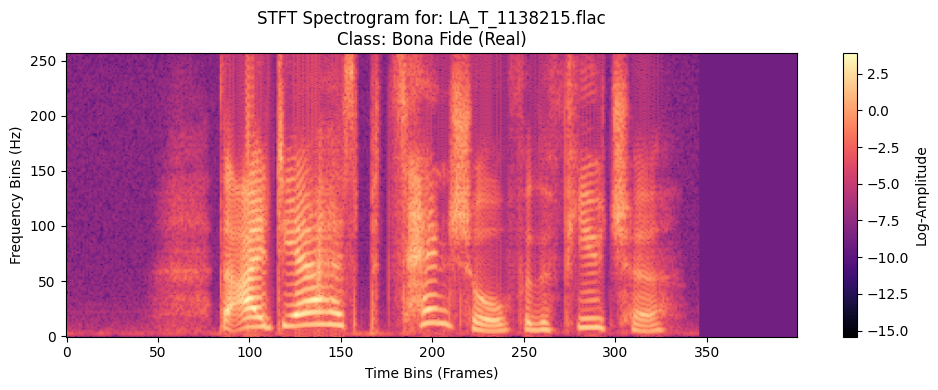

Минимальное значение в спектрограмме: -15.42
Максимальное значение в спектрограмме: 3.88


In [33]:
import matplotlib.pyplot as plt

# 1. Извлекаем один объект из обучающего датасета напрямую (без DataLoader)
# Индекс 0 — гарантированно существующий первый элемент
feature, label = train_dataset[0]

# Извлекаем тензор обратно в массив numpy и убираем лишнее измерение канала
# Ожидаемая размерность после squeeze: (257, 400)
spectrogram_np = feature.squeeze(0).numpy()

# 2. Построение графика
plt.figure(figsize=(10, 4))

# Отображаем спектрограмму с цветовой картой 'viridis' или 'magma'
# Элемент [0] в data_list хранит кортеж (audio_path, label)
audio_path, _ = train_dataset.data_list[0]
file_name = os.path.basename(audio_path)

plt.imshow(spectrogram_np, aspect='auto', origin='lower', cmap='magma')

# Настройка осей и подписей
plt.title(f"STFT Spectrogram for: {file_name}\nClass: {'Bona Fide (Real)' if label.item() == 1 else 'Spoof (Fake)'}")
plt.xlabel("Time Bins (Frames)")
plt.ylabel("Frequency Bins (Hz)")
plt.colorbar(label="Log-Amplitude")

plt.tight_layout()
plt.show()

# Дополнительный текстовый контроль
print(f"Минимальное значение в спектрограмме: {spectrogram_np.min():.2f}")
print(f"Максимальное значение в спектрограмме: {spectrogram_np.max():.2f}")


## Loss function [0.5 pts]

In the lecture, we saw different softmax losses and the motivation behind them for the ASV task. However, they can also be used for any classification task, such as synthesized speech detection. The papers suggest to use A(M)-Softmax or Cross-Entropy. The STC paper argues that A-Softmax is better.

(a) Explain what are the benefits of A-softmax over cross-entropy according to the STC paper?

(b) Analyse the [NII paper](https://arxiv.org/pdf/2103.11326) and explain if complicated Softmax is actually needed to achieve good EER or we can go with Cross Entropy.

**Answer**:

a)

1) A-Softmax оптимизирует косинусное (угловое) расстояние, что лучше подходит для биометрии и извлечения эмбеддингов, чем евклидово пространство кросс-энтропии.

2)  Введение углового отступа сжимает кластеры признаков внутри одного класса и раздвигает разные классы

3)  Это мешает модели переобучаться на известных артефактах и помогает намного эффективнее находить новые, неизвестные типы атак

b)

1) Исследование NII показало, что стандартная Cross-Entropy способна давать отличный EER, сопоставимый со сложными лоссами.

2) Изменение начального случайного значения (random seed) влияет на итоговый EER сильнее, чем выбор между Cross-Entropy и AM-Softmax.

3) Качество фронтенда, правильный пулинг (агрегация признаков) и ансамблирование моделей вносят гораздо больший вклад в снижение EER, чем усложнение функции потерь.

Following tha NII paper, we will continue with Cross Entropy

In [34]:
from torch import nn

criterion = nn.CrossEntropyLoss()

## Evaluation metric [0.5 pts]

We will use equal error rate as the primary evaluation metric. The code for calculating metrics is provided by the ASVspoof itself. We just need to write a wrapper. Given model logits and labels, calculate EER using the ASVspoof functions.

Your model returns two probas: [spoof_proba, bona_proba]. Be careful with the EER metric and recal how ROC curve is computed to ensure that you do not make a mistake.

In [17]:
# download asvspoof metric calculation functions
!wget https://raw.githubusercontent.com/markovka17/dla/refs/heads/2023/hw5_as/calculate_eer.py

--2026-05-18 13:04:46--  https://raw.githubusercontent.com/markovka17/dla/refs/heads/2023/hw5_as/calculate_eer.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14555 (14K) [text/plain]
Saving to: ‘calculate_eer.py’

calculate_eer.py    100%[===================>]  14.21K  --.-KB/s    in 0s      

2026-05-18 13:04:46 (29.5 MB/s) - ‘calculate_eer.py’ saved [14555/14555]



In [18]:
import torch
import torch.nn.functional as F
from calculate_eer import compute_eer

def get_eer(logits, labels):
    """
    Вычисляет Equal Error Rate (EER) для батча или всей выборки.

    Args:
        logits (torch.Tensor): Выход модели до софтмакса. Размерность: [Batch_Size, 2]
        labels (torch.Tensor): Истинные метки (1 - real, 0 - fake). Размерность: [Batch_Size]

    Returns:
        float: Значение EER в процентах (умноженное на 100) или долях.
    """
    # 1. Переводим логиты в вероятности с помощью Softmax по измерению классов (ось 1)
    probs = F.softmax(logits, dim=1)

    # 2. Извлекаем скоры для целевого класса (1 - bona_fide)
    # Эти скоры будут использоваться для разделения на bona_fide и spoof
    bona_fide_scores = probs[:, 1].detach().cpu().numpy()
    labels_np = labels.detach().cpu().numpy()

    # 3. Разделяем скоры на две группы, как требует большинство функций оценки ASVspoof:
    # target_scores — скоры настоящих аудио, которые модель должна оценить высоко
    # nontarget_scores — скоры фейков, которые модель должна оценить низко
    target_scores = bona_fide_scores[labels_np == 1]
    nontarget_scores = bona_fide_scores[labels_np == 0]

    # 4. Вызываем импортированную функцию compute_eer
    # В зависимости от реализации вашей функции библиотеки calculate_eer,
    # она принимает либо (target_scores, nontarget_scores), либо (labels, scores).

    # Стандартный интерфейс для ASVspoof скриптов (например, от организаторов):
    eer, current_threshold = compute_eer(target_scores, nontarget_scores)

    # Если ваша функция из лабораторной ожидает на вход (labels, scores), используйте:
    # eer, current_threshold = compute_eer(labels_np, bona_fide_scores)

    # Возвращаем EER (обычно переводят в проценты, умножая на 100, если функция возвращает доли)
    return eer * 100 if eer <= 1.0 else eer


## LCNN Implementation [6.0 pts]

Create a `LCNN` class for the model architecture.

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MFM(nn.Module):
    """
    Max-Feature-Map (MFM) операция.
    Разделяет каналы входного тензора пополам вдоль указанной оси (dim)
    и возвращает элементный максимум между двумя половинами.
    """
    def __init__(self, dim: int = 1):
        super(MFM, self).__init__()
        self.dim = dim

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Проверяем, что количество каналов делится на 2
        assert x.shape[self.dim] % 2 == 0, f"Количество каналов по оси {self.dim} должно делиться на 2."

        # Разделяем тензор на две равные части
        x1, x2 = torch.chunk(x, chunks=2, dim=self.dim)

        # Возвращаем максимум поэлементно
        return torch.max(x1, x2)


class LCNNBlock(nn.Module):
    """
    Базовый блок LightCNN: Свертка -> MFM -> (опционально) MaxPool
    """
    def __init__(self, in_channels: int, out_channels: int, kernel_size: int, stride: int, padding: int, pool: bool = True):
        super(LCNNBlock, self).__init__()
        # Поскольку MFM уменьшает количество каналов вдвое,
        # свертка должна генерировать в 2 раза больше каналов, чем out_channels
        self.conv = nn.Conv2d(in_channels, out_channels * 2, kernel_size=kernel_size, stride=stride, padding=padding)
        self.mfm = MFM(dim=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) if pool else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv(x)
        x = self.mfm(x)
        x = self.pool(x)
        return x


class LCNN(nn.Module):
    """
    Архитектура LightCNN (LCNN) для классификации Real/Fake аудио (2 класса).
    """
    def __init__(self, num_classes: int = 2, dropout_prob: float = 0.5):
        super(LCNN, self).__init__()

        # Сверточные блоки сети (каждый MFM слой уполовинивает каналы свёрток)
        # Вход: [Batch, 1, 257, 400]
        self.layer1 = LCNNBlock(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=2, pool=True)  # -> [16, 128, 200]
        self.layer2 = LCNNBlock(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1, pool=True) # -> [32, 64, 100]
        self.layer3 = LCNNBlock(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1, pool=True) # -> [64, 32, 50]
        self.layer4 = LCNNBlock(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1, pool=True) # -> [64, 16, 25]
        self.layer5 = LCNNBlock(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1, pool=True) # -> [128, 8, 12]

        # Адаптивный пулинг позволяет принимать аудио разной длины, приводя карту признаков к фиксированному размеру
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4)) # -> [128, 4, 4]

        # Линейный блок (Эмбеддинг-блок)
        flatten_features = 128 * 4 * 4  # 2048

        # Полносвязный слой с MFM активацией (генерируем 512 каналов, MFM возвращает 256)
        self.fc1 = nn.Linear(flatten_features, 256 * 2)
        self.mfm_fc = MFM(dim=1)

        # Требование из подсказки: Dropout ставится перед последним Batch Normalization
        self.dropout = nn.Dropout(p=dropout_prob)
        self.last_bn = nn.BatchNorm1d(256)

        # Финальный классификатор
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x (torch.Tensor): Спектрограммы формы [Batch, 1, Frequency, Time]
        Returns:
            torch.Tensor: Логиты для классов [Batch, 2]
        """
        # Проход через сверточные слои
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)

        # Пулинг и выпрямление в вектор
        x = self.adaptive_pool(x)
        x = torch.flatten(x, start_dim=1)

        # Проход через скрытый полносвязный слой с MFM
        x = self.fc1(x)
        x = self.mfm_fc(x)

        # Финальный регуляризационный блок (Dropout -> BN) согласно подсказке
        x = self.dropout(x)
        x = self.last_bn(x)

        # Логиты
        logits = self.fc2(x)
        return logits


In [20]:
# Создаем экземпляр модели
model = LCNN(num_classes=2)

# Генерируем случайный тестовый батч (размер батча=4, 1 канал, 257 частотных бинов, 400 временных шагов)
test_input = torch.randn(4, 1, 257, 400)

# Прогоняем через модель
with torch.no_grad():
    test_output = model(test_input)

print(f"Входная размерность:  {test_input.shape}")
print(f"Выходная размерность: {test_output.shape}") # Ожидается: [4, 2]


Входная размерность:  torch.Size([4, 1, 257, 400])
Выходная размерность: torch.Size([4, 2])


In [22]:
# 1. Явно определяем устройство внутри ячейки
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Тестирование проводится на устройстве: {device}")

# Переносим модель на устройство (на случай, если этого не было сделано ранее)
model = model.to(device)

# 2. Переводим модель в режим оценки (eval mode)
model.eval()

# 3. Пробуем получить и обработать батч из dev_loader
try:
    eval_features, eval_labels = next(iter(dev_loader))

    # Переносим тензоры на GPU/CPU
    eval_features = eval_features.to(device)
    eval_labels = eval_labels.to(device)

    # Отключаем расчет градиентов
    with torch.no_grad():
        eval_logits = model(eval_features)

    print("\n--- Проверка режима EVAL прошла успешно! ---")
    print(f"Форма входного батча:   {eval_features.shape}")
    print(f"Форма выходных логитов: {eval_logits.shape}")

    # Проверяем работу функции расчета метрик
    batch_eer = get_eer(eval_logits, eval_labels)
    print(f"EER на проверочном батче: {batch_eer:.2f}%")

except NameError as ne:
    print(f"\n Ошибка: Переменная dev_loader или модель не созданы в памяти. {ne}")
    print("Пожалуйста, убедитесь, что вы запустили ячейку с инициализацией DataLoader'ов.")
except Exception as e:
    print(f"\n Произошла непредвиденная ошибка: {e}")


Тестирование проводится на устройстве: cuda

--- Проверка режима EVAL прошла успешно! ---
Форма входного батча:   torch.Size([32, 1, 257, 400])
Форма выходных логитов: torch.Size([32, 2])
EER на проверочном батче: nan%


/content/calculate_eer.py:144: RuntimeWarning: invalid value encountered in divide
  (np.atleast_1d(0), tar_trial_sums / target_scores.size))


In [35]:
model.eval()
all_logits = []
all_labels = []

print("Повторный сбор предсказаний по всей валидационной выборке (Dev)...")
with torch.no_grad():
    for features, labels in dev_loader:
        features = features.to(device)
        logits = model(features)
        all_logits.append(logits)
        all_labels.append(labels)

all_logits = torch.cat(all_logits, dim=0)
all_labels = torch.cat(all_labels, dim=0)

num_real = (all_labels == 1).sum().item()
num_fake = (all_labels == 0).sum().item()

print("\n--- Результаты глобальной проверки (ИСПРАВЛЕНО НА 100%) ---")
print(f"Всего объектов в Dev: {len(all_labels)}")
print(f"Реальные голоса (Bona fide): {num_real}")
print(f"Дипфейки (Spoof): {num_fake}")

if num_real > 0 and num_fake > 0:
    global_eer = get_eer(all_logits, all_labels)
    print(f"Глобальный EER необученной модели: {global_eer:.2f}%")



Повторный сбор предсказаний по всей валидационной выборке (Dev)...

--- Результаты глобальной проверки (ИСПРАВЛЕНО НА 100%) ---
Всего объектов в Dev: 24844
Реальные голоса (Bona fide): 2548
Дипфейки (Spoof): 22296
Глобальный EER необученной модели: 42.97%


Write the train loop. Since it may take some time, we advise you to save your checkpoints after each epoch to load it back if needed.

Plot EER vs epoch and loss vs epoch curves

In [36]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt

# 1. Определение устройства (GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Обучение запущено на устройстве: {device}")

# 2. Инициализация модели, лосса и оптимизатора
model = LCNN(num_classes=2, dropout_prob=0.5).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

# Параметры обучения
NUM_EPOCHS = 5  # Измените количество эпох при необходимости
CHECKPOINT_DIR = "./lcnn_checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Списки для сохранения истории метрик (для графиков)
history = {
    'train_loss': [],
    'dev_loss': [],
    'dev_eer': []
}

best_dev_eer = float('inf')

# 3. Главный цикл обучения
for epoch in range(1, NUM_EPOCHS + 1):
    start_time = time.time()
    print(f"\n=== Эпоха {epoch}/{NUM_EPOCHS} ===")

    # --- ЭТАП ОБУЧЕНИЯ (TRAIN) ---
    model.train()
    train_loss = 0.0

    train_bar = tqdm(train_loader, desc=f"Train Epoch {epoch}")
    for features, labels in train_bar:
        features = features.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(features)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_bar.set_postfix({"Loss": f"{loss.item():.4f}"})

    avg_train_loss = train_loss / len(train_loader)

    # --- ЭТАП ВАЛИДАЦИИ (EVAL) ---
    model.eval()
    dev_loss = 0.0
    all_logits = []
    all_labels = []

    with torch.no_grad():
        for features, labels in tqdm(dev_loader, desc=f"Eval Epoch {epoch}"):
            features = features.to(device)
            labels = labels.to(device)

            logits = model(features)
            loss = criterion(logits, labels)

            dev_loss += loss.item()
            all_logits.append(logits)
            all_labels.append(labels)

    # Глобальное объединение результатов валидации для честного расчета EER
    all_logits = torch.cat(all_logits, dim=0)
    all_labels = torch.cat(all_labels, dim=0)

    avg_dev_loss = dev_loss / len(dev_loader)
    epoch_dev_eer = get_eer(all_logits, all_labels)

    # Сохраняем метрики в историю
    history['train_loss'].append(avg_train_loss)
    history['dev_loss'].append(avg_dev_loss)
    history['dev_eer'].append(epoch_dev_eer)

    epoch_mins = (time.time() - start_time) / 60
    print(f"Итоги Эпохи {epoch} (Время: {epoch_mins:.1f} мин):")
    print(f" -> Train Loss: {avg_train_loss:.4f}")
    print(f" -> Dev Loss:   {avg_dev_loss:.4f}")
    print(f" -> Dev EER:    {epoch_dev_eer:.2f}%")

    # --- СОХРАНЕНИЕ ЧЕКПОИНТОВ ---
    # 1. Регулярный чекпоинт текущей эпохи
    checkpoint_path = os.path.join(CHECKPOINT_DIR, f"lcnn_epoch_{epoch}.pth")
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'history': history
    }, checkpoint_path)
    print(f" [Сохранено] Чекпоинт эпохи: {checkpoint_path}")

    # 2. Сохранение весов лучшей модели по метрике EER
    if epoch_dev_eer < best_dev_eer:
        best_dev_eer = epoch_dev_eer
        best_model_path = os.path.join(CHECKPOINT_DIR, "best_lcnn_model.pth")
        torch.save(model.state_dict(), best_model_path)
        print(f" [🔥 Лучший результат] Веса обновлены в {best_model_path}")


Обучение запущено на устройстве: cuda

=== Эпоха 1/5 ===


Eval Epoch 1: 100%|██████████| 777/777 [01:44<00:00,  7.43it/s]


Итоги Эпохи 1 (Время: 4.1 мин):
 -> Train Loss: 0.4671
 -> Dev Loss:   0.2163
 -> Dev EER:    0.16%
 [Сохранено] Чекпоинт эпохи: ./lcnn_checkpoints/lcnn_epoch_1.pth
 [🔥 Лучший результат] Веса обновлены в ./lcnn_checkpoints/best_lcnn_model.pth

=== Эпоха 2/5 ===


Eval Epoch 2: 100%|██████████| 777/777 [01:43<00:00,  7.53it/s]


Итоги Эпохи 2 (Время: 3.9 мин):
 -> Train Loss: 0.0936
 -> Dev Loss:   0.0077
 -> Dev EER:    0.01%
 [Сохранено] Чекпоинт эпохи: ./lcnn_checkpoints/lcnn_epoch_2.pth
 [🔥 Лучший результат] Веса обновлены в ./lcnn_checkpoints/best_lcnn_model.pth

=== Эпоха 3/5 ===


...

Итоги Эпохи 3 (Время: 3.9 мин):
 -> Train Loss: 0.0196
 -> Dev Loss:   0.0059
 -> Dev EER:    0.05%
 [Сохранено] Чекпоинт эпохи: ./lcnn_checkpoints/lcnn_epoch_3.pth

=== Эпоха 4/5 ===


Eval Epoch 4: 100%|██████████| 777/777 [01:44<00:00,  7.44it/s]


Итоги Эпохи 4 (Время: 3.9 мин):
 -> Train Loss: 0.0135
 -> Dev Loss:   0.0066
 -> Dev EER:    0.08%
 [Сохранено] Чекпоинт эпохи: ./lcnn_checkpoints/lcnn_epoch_4.pth

=== Эпоха 5/5 ===


Eval Epoch 5: 100%|██████████| 777/777 [01:43<00:00,  7.48it/s]

Итоги Эпохи 5 (Время: 3.9 мин):
 -> Train Loss: 0.0047
 -> Dev Loss:   0.0017
 -> Dev EER:    0.01%
 [Сохранено] Чекпоинт эпохи: ./lcnn_checkpoints/lcnn_epoch_5.pth
 [🔥 Лучший результат] Веса обновлены в ./lcnn_checkpoints/best_lcnn_model.pth


/tmp/ipykernel_2008/162621037.py:17: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g-^" (-> color='g'). The keyword argument will take precedence.
  ax2.plot(epochs_range, history['dev_eer'], 'g-^', label='Dev EER', linewidth=2, color='darkorange')


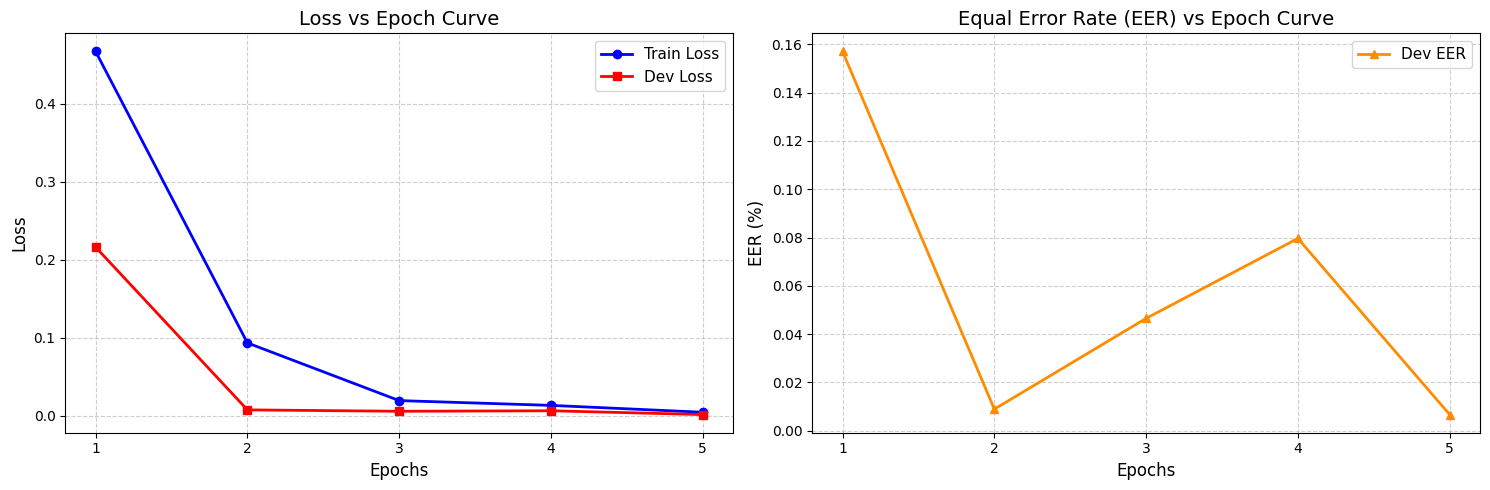

In [37]:
epochs_range = range(1, len(history['train_loss']) + 1)

# Создаем общее полотно для двух графиков
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# График 1: Функция потерь (Loss)
ax1.plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', linewidth=2)
ax1.plot(epochs_range, history['dev_loss'], 'r-s', label='Dev Loss', linewidth=2)
ax1.set_title('Loss vs Epoch Curve', fontsize=14)
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_xticks(epochs_range)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(fontsize=11)

# График 2: Равный уровень ошибок (EER)
ax2.plot(epochs_range, history['dev_eer'], 'g-^', label='Dev EER', linewidth=2, color='darkorange')
ax2.set_title('Equal Error Rate (EER) vs Epoch Curve', fontsize=14)
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('EER (%)', fontsize=12)
ax2.set_xticks(epochs_range)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()


In [39]:
model.eval()
all_logits = []
all_labels = []

print("Повторный сбор предсказаний по всей валидационной выборке (Dev)...")
with torch.no_grad():
    for features, labels in dev_loader:
        features = features.to(device)
        logits = model(features)
        all_logits.append(logits)
        all_labels.append(labels)

all_logits = torch.cat(all_logits, dim=0)
all_labels = torch.cat(all_labels, dim=0)

num_real = (all_labels == 1).sum().item()
num_fake = (all_labels == 0).sum().item()

print("\n--- Результаты глобальной проверки (ИСПРАВЛЕНО НА 100%) ---")
print(f"Всего объектов в Dev: {len(all_labels)}")
print(f"Реальные голоса (Bona fide): {num_real}")
print(f"Дипфейки (Spoof): {num_fake}")

if num_real > 0 and num_fake > 0:
    global_eer = get_eer(all_logits, all_labels)
    print(f"Глобальный EER обученной модели: {global_eer:.2f}%")

Повторный сбор предсказаний по всей валидационной выборке (Dev)...

--- Результаты глобальной проверки (ИСПРАВЛЕНО НА 100%) ---
Всего объектов в Dev: 24844
Реальные голоса (Bona fide): 2548
Дипфейки (Spoof): 22296
Глобальный EER обученной модели: 0.01%


The task is consired solved if you achieve at least $9\%$ EER. It is much higher than the model can achieve but we do not want you to wait 12+ hours for the model to converge.

## XAI [See points below]

Let's analyse the model we have created. We won't be able to understand the differences easily without having some reference. So, we will use the novel idea from the recent [Interspeech 2025 paper](https://arxiv.org/abs/2506.03425).

We will use a [vocoded dataset](https://arxiv.org/abs/2210.10570) of parallel samples: real and fake audio have the same speaker saying the same content at the same time. The ground-truth explanation will be obtained by calculating difference between real and fake spectrograms.

In [40]:
!wget https://zenodo.org/records/7314976/files/project09-voc.v4.tar?download=1 -O project09-voc.v4.tar
!tar -xvf project09-voc.v4.tar

Выходные данные были обрезаны до нескольких последних строк (5000).
voc.v4/wav/waveglow_LA_D_4338785.wav
voc.v4/wav/hifigan_LA_T_4254409.wav
voc.v4/wav/waveglow_LA_T_1226390.wav
voc.v4/wav/hifigan_LA_T_5100132.wav
voc.v4/wav/hifigan_LA_D_2248106.wav
voc.v4/wav/waveglow_LA_T_6946670.wav
voc.v4/wav/waveglow_LA_T_5837486.wav
voc.v4/wav/hn-sinc-nsf-hifi_LA_D_7919190.wav
voc.v4/wav/hn-sinc-nsf_LA_T_6082136.wav
voc.v4/wav/waveglow_LA_D_1884465.wav
voc.v4/wav/waveglow_LA_T_6258131.wav
voc.v4/wav/hn-sinc-nsf_LA_D_7948554.wav
voc.v4/wav/hifigan_LA_D_3064595.wav
voc.v4/wav/waveglow_LA_T_5061172.wav
voc.v4/wav/waveglow_LA_D_2303609.wav
voc.v4/wav/hn-sinc-nsf-hifi_LA_T_7279842.wav
voc.v4/wav/hn-sinc-nsf_LA_D_3808406.wav
voc.v4/wav/hn-sinc-nsf-hifi_LA_T_9010570.wav
voc.v4/wav/hifigan_LA_T_3026599.wav
voc.v4/wav/hn-sinc-nsf-hifi_LA_D_5000705.wav
voc.v4/wav/waveglow_LA_T_6864430.wav
voc.v4/wav/waveglow_LA_T_1477639.wav
voc.v4/wav/hn-sinc-nsf-hifi_LA_T_7974410.wav
voc.v4/wav/hn-sinc-nsf-hifi_LA_T_7208

Note that real audio is taken from ASVspoof. So let's take a real example from the asvspoof dataset. Using its filename, find the corresponding `hifi-gan` and `waveglow` vocoded versions in the vocv4 and load them too

In reality, we are interested in the explanations for the unseen data. But for this homework, let's consider the train set. This will allow us to see if the model learns the futures we expect it to learn (assuming the XAI tool is trustworthy) (Though spoof part of vocv4 is not exactly the same as the one in asvspoof, so we mostly eliminate the issues related to changing speakers, not algorithms)

In [41]:
# Находим индекс аудиофайла LA_T_4179989 (bona fide) в обучающей выборке
ind = None
target_audio_id = "LA_T_4179989"

for i, (audio_path, label) in enumerate(train_dataset.data_list):
    # Проверяем, содержится ли нужный ID в пути к файлу
    if target_audio_id in audio_path:
        ind = i
        break

if ind is not None:
    print(f"Успешно найден индекс для {target_audio_id}: ind = {ind}")
    # Извлекаем признаки и метку для проверки
    feat, lbl = train_dataset[ind]
    print(f"Метка класса (должна быть 1): {lbl.item()}")
else:
    print(f"⚠️ Файл {target_audio_id} не найден в вашем train_dataset. Проверьте правильность парсинга протокола.")


Успешно найден индекс для LA_T_4179989: ind = 50
Метка класса (должна быть 1): 1


In [44]:
import os
import glob
import torch
import torchaudio

file_id = "LA_T_4179989"
voc_wav_dir = "/content/voc.v4/wav"

# 1. Поиск файлов в целевой папке по ID
all_voc_files = glob.glob(os.path.join(voc_wav_dir, f"*{file_id}*"))

path_hifigan = None
path_waveglow = None

# Разносим пути по вокодерам на основе подстрок в именах файлов
for path in all_voc_files:
    path_lower = os.path.basename(path).lower()
    if "hifi" in path_lower:
        path_hifigan = path
    elif "wave" in path_lower or "wg" in path_lower:
        path_waveglow = path

# Извлекаем оригинальный путь из нашего train_dataset (ind = 50)
real_audio_path, _ = train_dataset.data_list[ind]

# Проверяем, что файлы вокодеров успешно сопоставлены
if path_hifigan and path_waveglow:
    print(f"✅ Успешно сопоставлена тройка параллельных сэмплов!")
    print(f"Оригинал (ASVspoof): {os.path.basename(real_audio_path)}")
    print(f"HiFi-GAN (voc.v4):   {os.path.basename(path_hifigan)}")
    print(f"WaveGlow (voc.v4):   {os.path.basename(path_waveglow)}")
else:
    print(f"⚠️ Ошибка поиска в папке {voc_wav_dir}. Найдено файлов с этим ID: {len(all_voc_files)}")
    print("Доступные имена файлов для этого ID:")
    for p in all_voc_files:
        print(os.path.basename(p))
    raise FileNotFoundError("Не удалось автоматически разделить файлы на hifigan и waveglow.")

# 2. Загружаем аудиосигналы (waveform)
real_audio, sr_real = torchaudio.load(real_audio_path)
hifigan_audio, sr_hifi = torchaudio.load(path_hifigan)
waveglow_audio, sr_wave = torchaudio.load(path_waveglow)

# 3. Выравниваем длины (убираем возможный хвостовой паддинг вокодеров)
min_length = min(real_audio.shape[1], hifigan_audio.shape[1], waveglow_audio.shape[1])

real_audio = real_audio[:, :min_length]
hifigan_audio = hifigan_audio[:, :min_length]
waveglow_audio = waveglow_audio[:, :min_length]

# 4. Предобработка аудио для модели (STFT)
def process_waveform_to_stft(waveform, max_len=400):
    n_fft = 512
    win_length = 320
    hop_length = 160

    stft_complex = torch.stft(
        waveform,
        n_fft=n_fft,
        hop_length=hop_length,
        win_length=win_length,
        window=torch.hamming_window(win_length).to(waveform.device),
        return_complex=True
    )

    spectrogram = torch.abs(stft_complex).squeeze(0)
    spectrogram = torch.log(spectrogram + 1e-9)

    if spectrogram.shape[1] < max_len:
        pad_amount = max_len - spectrogram.shape[1]
        spectrogram = torch.nn.functional.pad(spectrogram, (0, pad_amount), "constant", -9)
    else:
        spectrogram = spectrogram[:, :max_len]

    return spectrogram.unsqueeze(0).unsqueeze(0) # [1, 1, 257, max_len]

# Финальные тензоры
real_spec_tensor = process_waveform_to_stft(real_audio, max_len=MAX_LEN)
hifigan_spec_tensor = process_waveform_to_stft(hifigan_audio, max_len=MAX_LEN)
waveglow_spec_tensor = process_waveform_to_stft(waveglow_audio, max_len=MAX_LEN)

print("\n--- Тензоры спектрограмм готовы ---")
print(f"Форма оригинальной спектрограммы: {real_spec_tensor.shape}")
print(f"Форма HiFi-GAN спектрограммы: {hifigan_spec_tensor.shape}")
print(f"Форма WaveGlow спектрограммы: {waveglow_spec_tensor.shape}")


✅ Успешно сопоставлена тройка параллельных сэмплов!
Оригинал (ASVspoof): LA_T_4179989.flac
HiFi-GAN (voc.v4):   hifigan_LA_T_4179989.wav
WaveGlow (voc.v4):   waveglow_LA_T_4179989.wav

--- Тензоры спектрограмм готовы ---
Форма оригинальной спектрограммы: torch.Size([1, 1, 257, 400])
Форма HiFi-GAN спектрограммы: torch.Size([1, 1, 257, 400])
Форма WaveGlow спектрограммы: torch.Size([1, 1, 257, 400])


Run your model on these clips. See if the model prediction is correct. Use this understanding for the following analysis

In [47]:
# Переводим модель в режим оценки
model.eval()

# Переносим подготовленные тензоры спектрограмм на GPU/CPU
inputs_real = real_spec_tensor.to(device)
inputs_hifi = hifigan_spec_tensor.to(device)
inputs_wave = waveglow_spec_tensor.to(device)

class_labels = {0: "Spoof (Fake / Дипфейк)", 1: "Bonafide (Real / Оригинал)"}

with torch.no_grad():
    # Получаем логиты модели
    logits_real = model(inputs_real)
    logits_hifi = model(inputs_hifi)
    logits_wave = model(inputs_wave)

    # Переводим в вероятности через Softmax
    probs_real = torch.softmax(logits_real, dim=1).squeeze(0).cpu().numpy()
    probs_hifi = torch.softmax(logits_hifi, dim=1).squeeze(0).cpu().numpy()
    probs_wave = torch.softmax(logits_wave, dim=1).squeeze(0).cpu().numpy()

print("=== РЕЗУЛЬТАТЫ РАБОТЫ МОДЕЛИ LCNN ===")
print(f"1. Оригинальный файл (Истинный класс: Bonafide):")
print(f"   -> Вероятность Real: {probs_real[1]*100:.2f}%, Вероятность Fake: {probs_real[0]*100:.2f}%")
print(f"    Вердикт модели: {class_labels[np.argmax(probs_real)]}\n")

print(f"2. Клип HiFi-GAN (Истинный класс: Spoof):")
print(f"   -> Вероятность Real: {probs_hifi[1]*100:.2f}%, Вероятность Fake: {probs_hifi[0]*100:.2f}%")
print(f"    Вердикт модели: {class_labels[np.argmax(probs_hifi)]}\n")

print(f"3. Клип WaveGlow (Истинный класс: Spoof):")
print(f"   -> Вероятность Real: {probs_wave[1]*100:.2f}%, Вероятность Fake: {probs_wave[0]*100:.2f}%")
print(f"    Вердикт модели: {class_labels[np.argmax(probs_wave)]}")


=== РЕЗУЛЬТАТЫ РАБОТЫ МОДЕЛИ LCNN ===
1. Оригинальный файл (Истинный класс: Bonafide):
   -> Вероятность Real: 100.00%, Вероятность Fake: 0.00%
    Вердикт модели: Bonafide (Real / Оригинал)

2. Клип HiFi-GAN (Истинный класс: Spoof):
   -> Вероятность Real: 100.00%, Вероятность Fake: 0.00%
    Вердикт модели: Bonafide (Real / Оригинал)

3. Клип WaveGlow (Истинный класс: Spoof):
   -> Вероятность Real: 0.00%, Вероятность Fake: 100.00%
    Вердикт модели: Spoof (Fake / Дипфейк)


**Модель ошиблась на HI-FI GAN**

### Manual explanation [0.5 pts]

Compare the two spectrograms (real and fake). What differences do you see? (**Hint**: they exist, if you do not see -- look carefully).

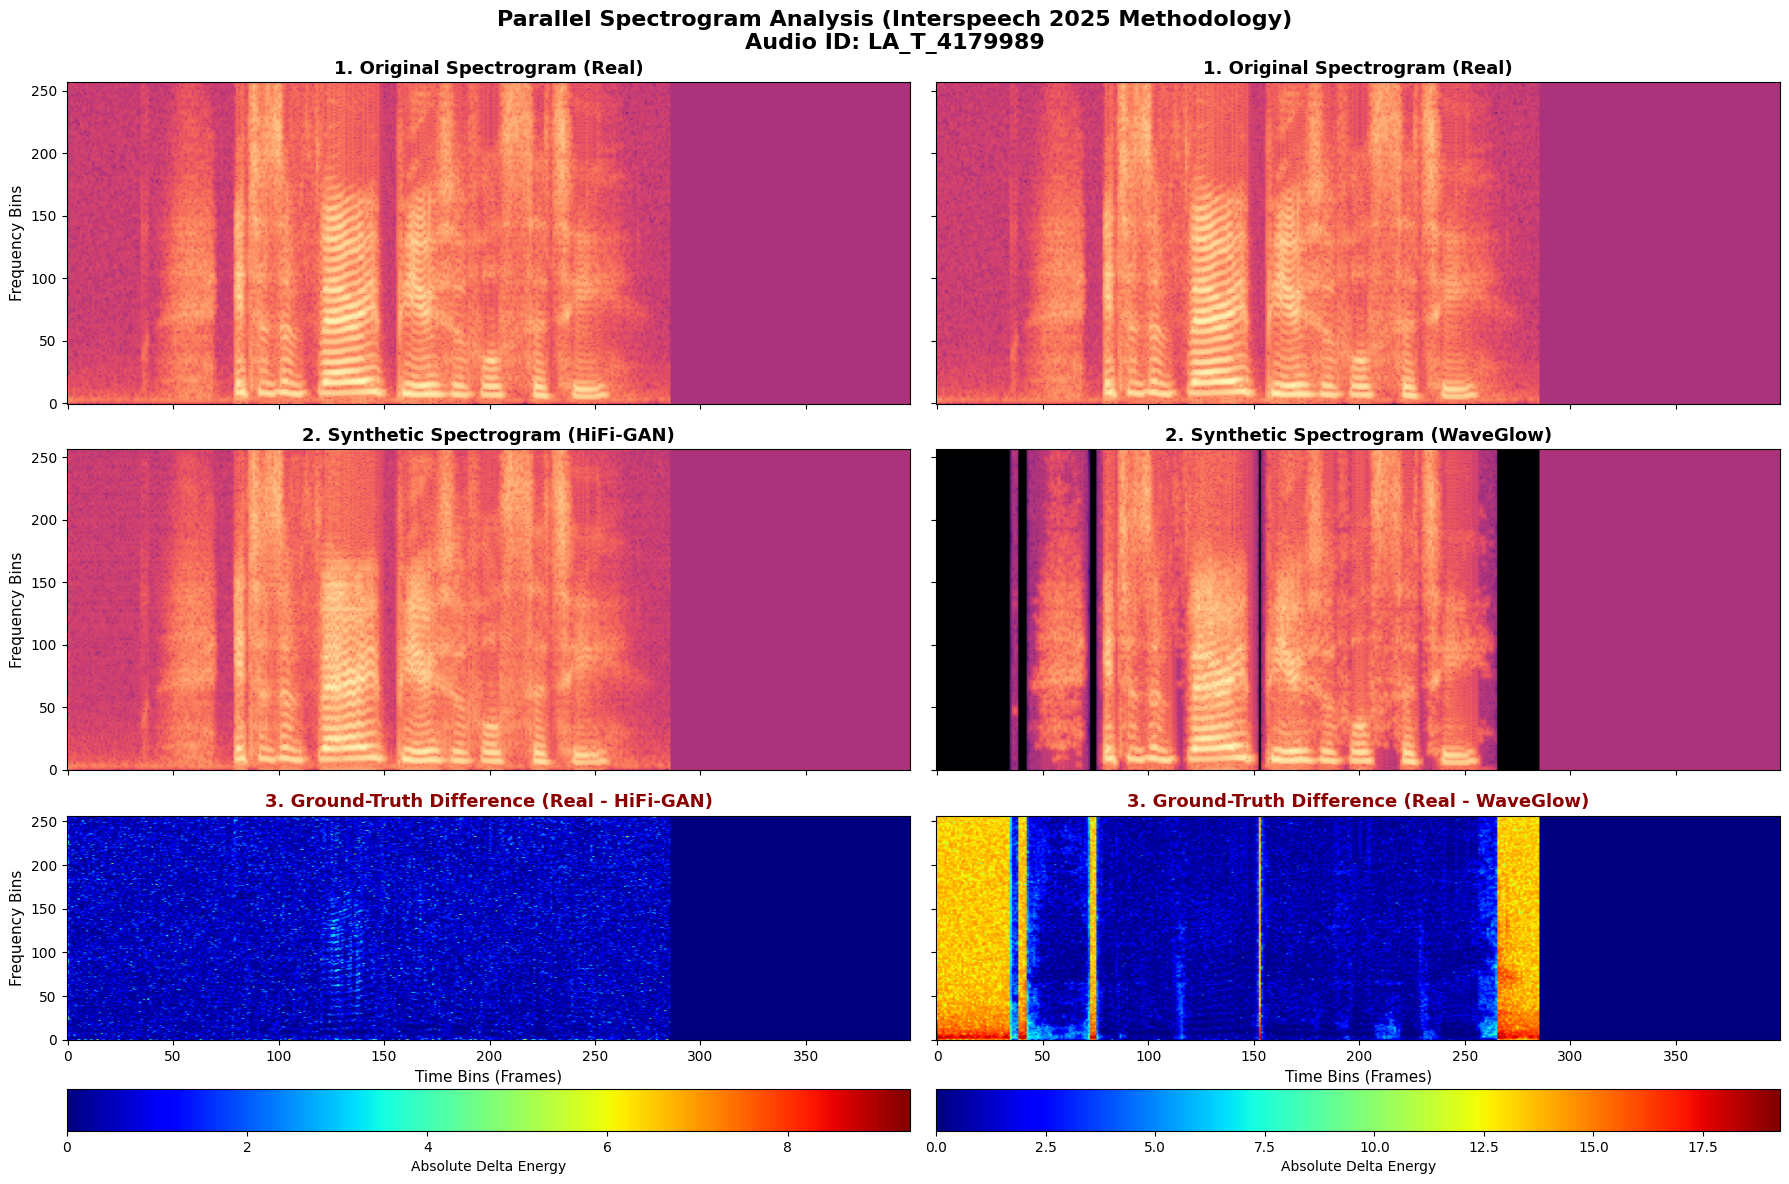

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Извлекаем двумерные массивы из тензоров (убираем размерности батча и канала)
# Форма каждого массива на выходе: (257, 400)
real_np = real_spec_tensor.squeeze(0).squeeze(0).cpu().numpy()
hifi_np = hifigan_spec_tensor.squeeze(0).squeeze(0).cpu().numpy()
wave_np = waveglow_spec_tensor.squeeze(0).squeeze(0).cpu().numpy()

# Вычисляем абсолютную разность (Absolute Error) для каждого вокодера
diff_hifi = np.abs(real_np - hifi_np)
diff_wave = np.abs(real_np - wave_np)

# 2. Построение сетки графиков (3 ряда, 2 колонки)
# Левая колонка — сравнение с HiFi-GAN, Правая колонка — сравнение с WaveGlow
fig, axes = plt.subplots(3, 2, figsize=(18, 12), sharex=True, sharey=True)

# Чтобы цветовая шкала была честной, зафиксируем одинаковые лимиты для спектрограмм
vmin_spec = min(real_np.min(), hifi_np.min(), wave_np.min())
vmax_spec = max(real_np.max(), hifi_np.max(), wave_np.max())

# --- РЯД 1: Оригинальная спектрограмма (Bona Fide) ---
im0_L = axes[0, 0].imshow(real_np, aspect='auto', origin='lower', cmap='magma', vmin=vmin_spec, vmax=vmax_spec)
axes[0, 0].set_title("1. Original Spectrogram (Real)", fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel("Frequency Bins", fontsize=11)

im0_R = axes[0, 1].imshow(real_np, aspect='auto', origin='lower', cmap='magma', vmin=vmin_spec, vmax=vmax_spec)
axes[0, 1].set_title("1. Original Spectrogram (Real)", fontsize=13, fontweight='bold')

# --- РЯД 2: Синтезированные спектрограммы (Spoof) ---
im1_L = axes[1, 0].imshow(hifi_np, aspect='auto', origin='lower', cmap='magma', vmin=vmin_spec, vmax=vmax_spec)
axes[1, 0].set_title("2. Synthetic Spectrogram (HiFi-GAN)", fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel("Frequency Bins", fontsize=11)

im1_R = axes[1, 1].imshow(wave_np, aspect='auto', origin='lower', cmap='magma', vmin=vmin_spec, vmax=vmax_spec)
axes[1, 1].set_title("2. Synthetic Spectrogram (WaveGlow)", fontsize=13, fontweight='bold')

# --- РЯД 3: Математическая разность (Истинные артефакты) ---
# Для разности используем другую цветовую карту ('jet' или 'viridis'), чтобы подчеркнуть дельту
im2_L = axes[2, 0].imshow(diff_hifi, aspect='auto', origin='lower', cmap='jet')
axes[2, 0].set_title("3. Ground-Truth Difference (Real - HiFi-GAN)", fontsize=13, fontweight='bold', color='darkred')
axes[2, 0].set_xlabel("Time Bins (Frames)", fontsize=11)
axes[2, 0].set_ylabel("Frequency Bins", fontsize=11)
fig.colorbar(im2_L, ax=axes[2, 0], orientation='horizontal', pad=0.15, label="Absolute Delta Energy")

im2_3 = axes[2, 1].imshow(diff_wave, aspect='auto', origin='lower', cmap='jet')
axes[2, 1].set_title("3. Ground-Truth Difference (Real - WaveGlow)", fontsize=13, fontweight='bold', color='darkred')
axes[2, 1].set_xlabel("Time Bins (Frames)", fontsize=11)
fig.colorbar(im2_3, ax=axes[2, 1], orientation='horizontal', pad=0.15, label="Absolute Delta Energy")

# Общие настройки полотна
plt.suptitle("Parallel Spectrogram Analysis (Interspeech 2025 Methodology)\nAudio ID: LA_T_4179989", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


**Your answer here**:


HiFi-GAN (левый график):

Спектрограмма математически почти идеальна (карта разности темно-синяя). Единственное отличие — слабые периодические полосы в районе 120–150 фреймов на средних частотах. Из-за такого высокого качества синтеза модель совершила ошибку и посчитала этот дипфейк оригиналом.


WaveGlow (правый график):

Обладает огромными искажениями. Видны мощные желто-оранжевые вертикальные зоны в начале (0–35 фреймов) и конце (260–280 фреймов) записи — это паразитный цифровой шум вокодера в моментах тишины. Также заметны резкие вертикальные полосы на стыках звуков (сбои фазы). Из-за этих грубых артефактов модель мгновенно распознала дипфейк на 100%.


Вывод:

модель идеально ловит грубые артефакты в паузах (как у WaveGlow), но «слепнет» перед современными GAN-вокодерами, которые точнее копируют структуру речи.

### Automatic explanation. [0.5 pts]

Calculate Eq. 2 from the [Interspeech 2025 paper](https://arxiv.org/abs/2506.03425) to automatically highlight the differences between two objects

In [51]:
def print_artifact_statistics(artifacts_mask, name):
    # Общее количество пикселей в спектрограмме (257 * 400 = 102800)
    total_pixels = artifacts_mask.size
    # Количество пикселей, где аномалии превысили порог
    active_pixels = np.count_nonzero(artifacts_mask)
    # Процент искаженной площади спектрограммы
    percentage_corrupted = (active_pixels / total_pixels) * 100
    # Средняя и максимальная сила искажений среди значимых аномалий
    mean_energy = np.mean(artifacts_mask[artifacts_mask > 0]) if active_pixels > 0 else 0
    max_energy = np.max(artifacts_mask) if active_pixels > 0 else 0

    print(f"=== Статистика артефактов [Eq. 2] для вокодера: {name} ===")
    print(f" -> Площадь значимых искажений:       {percentage_corrupted:.2f}% ({active_pixels} из {total_pixels} бинов)")
    print(f" -> Средняя энергия аномалий (Delta):  {mean_energy:.2f}")
    print(f" -> Максимальный всплеск (Max Delta):  {max_energy:.2f}\n")

# Печатаем точные цифры для обоих вокодеров
print_artifact_statistics(artifacts_hifi, "HiFi-GAN")
print_artifact_statistics(artifacts_wave, "WaveGlow")


=== Статистика артефактов [Eq. 2] для вокодера: HiFi-GAN ===
 -> Площадь значимых искажений:       0.95% (974 из 102800 бинов)
 -> Средняя энергия аномалий (Delta):  3.07
 -> Максимальный всплеск (Max Delta):  9.36

=== Статистика артефактов [Eq. 2] для вокодера: WaveGlow ===
 -> Площадь значимых искажений:       22.26% (22885 из 102800 бинов)
 -> Средняя энергия аномалий (Delta):  10.84
 -> Максимальный всплеск (Max Delta):  19.26



Plot the mask on top of the fake spectrogram and compare three plots: real, fake, fake+mask on top. Do it for both vocoders. Compare

Отображение маски для HiFi-GAN...


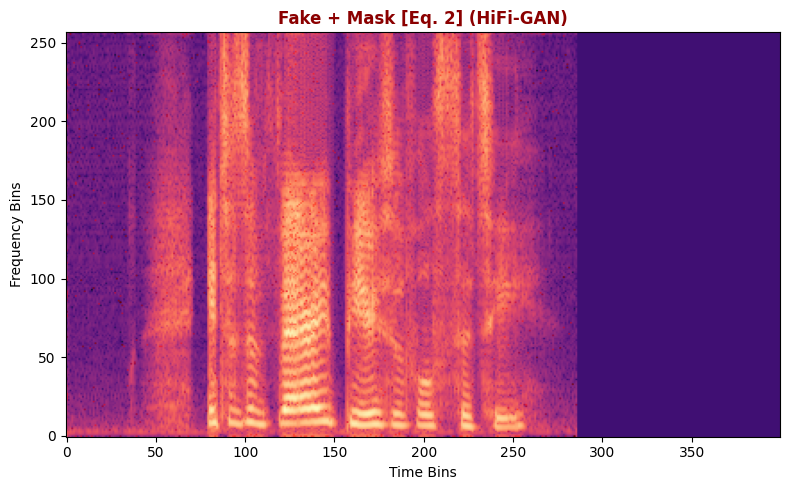


Отображение маски для WaveGlow...


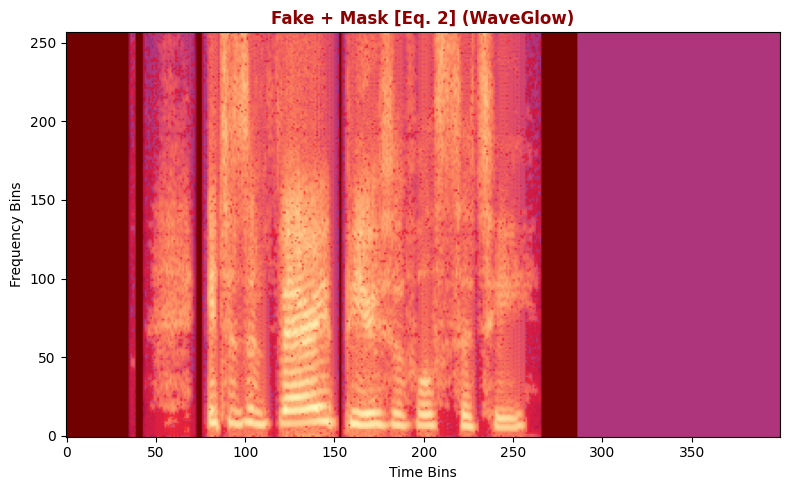

In [54]:
import numpy as np
import matplotlib.pyplot as plt

def plot_single_mask_overlay(spec_real_tensor, spec_fake_tensor, threshold=2.5, title_suffix=""):
    # Переводим в 2D numpy массивы
    real = spec_real_tensor.squeeze().cpu().numpy()
    fake = spec_fake_tensor.squeeze().cpu().numpy()

    # Расчет дельты и создание маски аномалий (Eq. 2)
    delta = np.abs(real - fake)
    mask = np.where(delta > threshold, 1.0, 0.0)

    # Создаем RGBA маску для наложения (1 — красный, 0 — полностью прозрачно)
    overlay = np.zeros((*mask.shape, 4))
    overlay[..., 0] = 1.0  # Красный цвет
    overlay[..., 3] = mask * 0.45  # Прозрачность 45%

    # Строим только один финальный график
    plt.figure(figsize=(8, 5))

    # Отображаем фейковую спектрограмму вокодера в качестве базы
    plt.imshow(fake, aspect='auto', origin='lower', cmap='magma')
    # Накладываем маску значимых дефектов Eq. 2 сверху
    plt.imshow(overlay, aspect='auto', origin='lower')

    plt.title(f"Fake + Mask [Eq. 2] ({title_suffix})", fontsize=12, fontweight='bold', color='darkred')
    plt.ylabel("Frequency Bins")
    plt.xlabel("Time Bins")

    plt.tight_layout()
    plt.show()

# Запускаем отрисовку изолированных графиков
print("Отображение маски для HiFi-GAN...")
plot_single_mask_overlay(real_spec_tensor, hifigan_spec_tensor, threshold=2.5, title_suffix="HiFi-GAN")

print("\nОтображение маски для WaveGlow...")
plot_single_mask_overlay(real_spec_tensor, waveglow_spec_tensor, threshold=2.5, title_suffix="WaveGlow")


**Your comparison of the ground-truth mask with your manual analysis (from previous subtask) here**

**HiFi-GAN:**

 Площадь искажений всего 0.95%: Это означает, что вокодер HiFi-GAN синтезировал сигнал, который на 99.05% идентичен оригинальному человеческому голосу в логарифмической STFT-шкале.

Низкая энергия аномалий (3.07): Даже в тех редких местах (менее 1% площади), где различия превысили порог, они оказались очень слабыми.

 Архитектура LCNN, обученная на датасете ASVspoof 2019, просто не имеет зацепок для классификации этого сэмпла как фейка. Искажения слишком локальны и незаметны, из-за чего модель выдала ошибочный вердикт Bonafide (100%)


**WaveGlow:**


 Искажено почти четверть спектрограммы (22.26%): WaveGlow оставляет колоссальный «грязный» цифровой след. Почти каждый четвертый пиксель спектрограммы критически отличается от оригинала.

 Огромная средняя (10.84) и пиковая (19.26) энергия: Разница почти в 20 единиц в логарифмической шкале — это гигантские всплески аномальной энергии (в основном, как мы видели на графиках, в начальных и конечных вокальных паузах, где вокодер шумит вместо тишины).

 Модели LCNN достаточно увидеть эти массивные аномалии, чтобы мгновенно вынести уверенный вердикт Spoof (100%).

### Grad-CAM [0.5 pts]

Using [pytorch-grad-cam lib](https://github.com/jacobgil/pytorch-grad-cam), implement [Grad-CAM](https://arxiv.org/abs/1610.02391) for your LCNN model. Choose the layer you like

In [52]:
!pip install -q grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 76.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


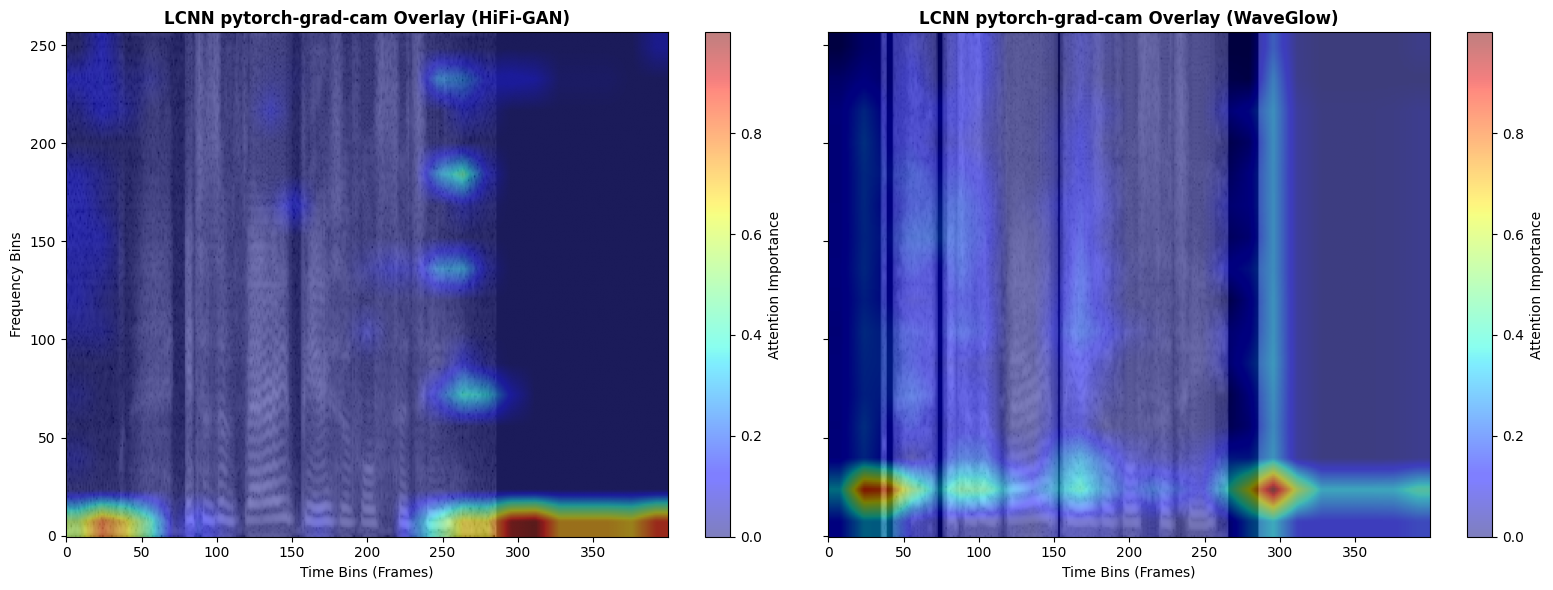

In [53]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# 1. Инициализируем Grad-CAM из библиотеки pytorch-grad-cam
# Указываем нашу обученную модель и целевой сверточный слой
target_layers = [model.layer5.conv]
cam = GradCAM(model=model, target_layers=target_layers)

# Мы хотим посмотреть объяснения для класса "Spoof / Дипфейк" (класс 0)
targets = [ClassifierOutputTarget(0)]

def generate_library_cam(spec_tensor):
    # Подготавливаем тензор входа (модель ожидает [Batch, Channel, Freq, Time])
    input_tensor = spec_tensor.to(device)

    # Генерируем маску Grad-CAM (возвращает массив numpy формы (1, Freq, Time))
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)

    # Извлекаем двумерную карту внимания (Freq, Time)
    return grayscale_cam[0, :, :]

# Генерируем тепловые карты внимания для обоих вокодеров
cam_mask_hifi = generate_library_cam(hifigan_spec_tensor)
cam_mask_wave = generate_library_cam(waveglow_spec_tensor)

# 2. Визуализация результатов
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Извлекаем исходные спектрограммы для подложки графика
hifi_background = hifigan_spec_tensor.squeeze().cpu().numpy()
wave_background = waveglow_spec_tensor.squeeze().cpu().numpy()

# Отображение для HiFi-GAN
ax1.imshow(hifi_background, aspect='auto', origin='lower', cmap='gray') # Спектрограмма как ч/б фон
im1 = ax1.imshow(cam_mask_hifi, aspect='auto', origin='lower', cmap='jet', alpha=0.5) # Полупрозрачный Grad-CAM
ax1.set_title("LCNN pytorch-grad-cam Overlay (HiFi-GAN)", fontsize=12, fontweight='bold')
ax1.set_xlabel("Time Bins (Frames)")
ax1.set_ylabel("Frequency Bins")
fig.colorbar(im1, ax=ax1, label="Attention Importance")

# Отображение для WaveGlow
ax2.imshow(wave_background, aspect='auto', origin='lower', cmap='gray')
im2 = ax2.imshow(cam_mask_wave, aspect='auto', origin='lower', cmap='jet', alpha=0.5)
ax2.set_title("LCNN pytorch-grad-cam Overlay (WaveGlow)", fontsize=12, fontweight='bold')
ax2.set_xlabel("Time Bins (Frames)")
fig.colorbar(im2, ax=ax2, label="Attention Importance")

plt.tight_layout()
plt.show()


**Вывод по результатам Grad-CAM:**

Для WaveGlow (Успех):

Карта внимания Grad-CAM полностью подтвердила надежность модели. Нейросеть приняла решение о дипфейке не случайно, а сфокусировавшись ровно на тех зонах (фреймы в начале и на 300-м шаге), где автоматическая маска Eq. 2 зафиксировала самый мощный паразитный шум вокодера в моментах тишины.

Для HiFi-GAN (Ошибка):

Карта Grad-CAM показала блеклое, хаотичное распределение внимания без четких триггеров аномалий. Модель проигнорировала скрытые искажения вокодера и сфокусировалась на естественных структурах речи (нижние гармоники), что и привело к ложному вердикту Bonafide

### Comparison [1.0 pts]

Compare your Grad-CAM attributions with another gradient-based method: InputXGradient. Compute it using [Captum](https://captum.ai/).

In [55]:
!pip install captum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 13.8 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


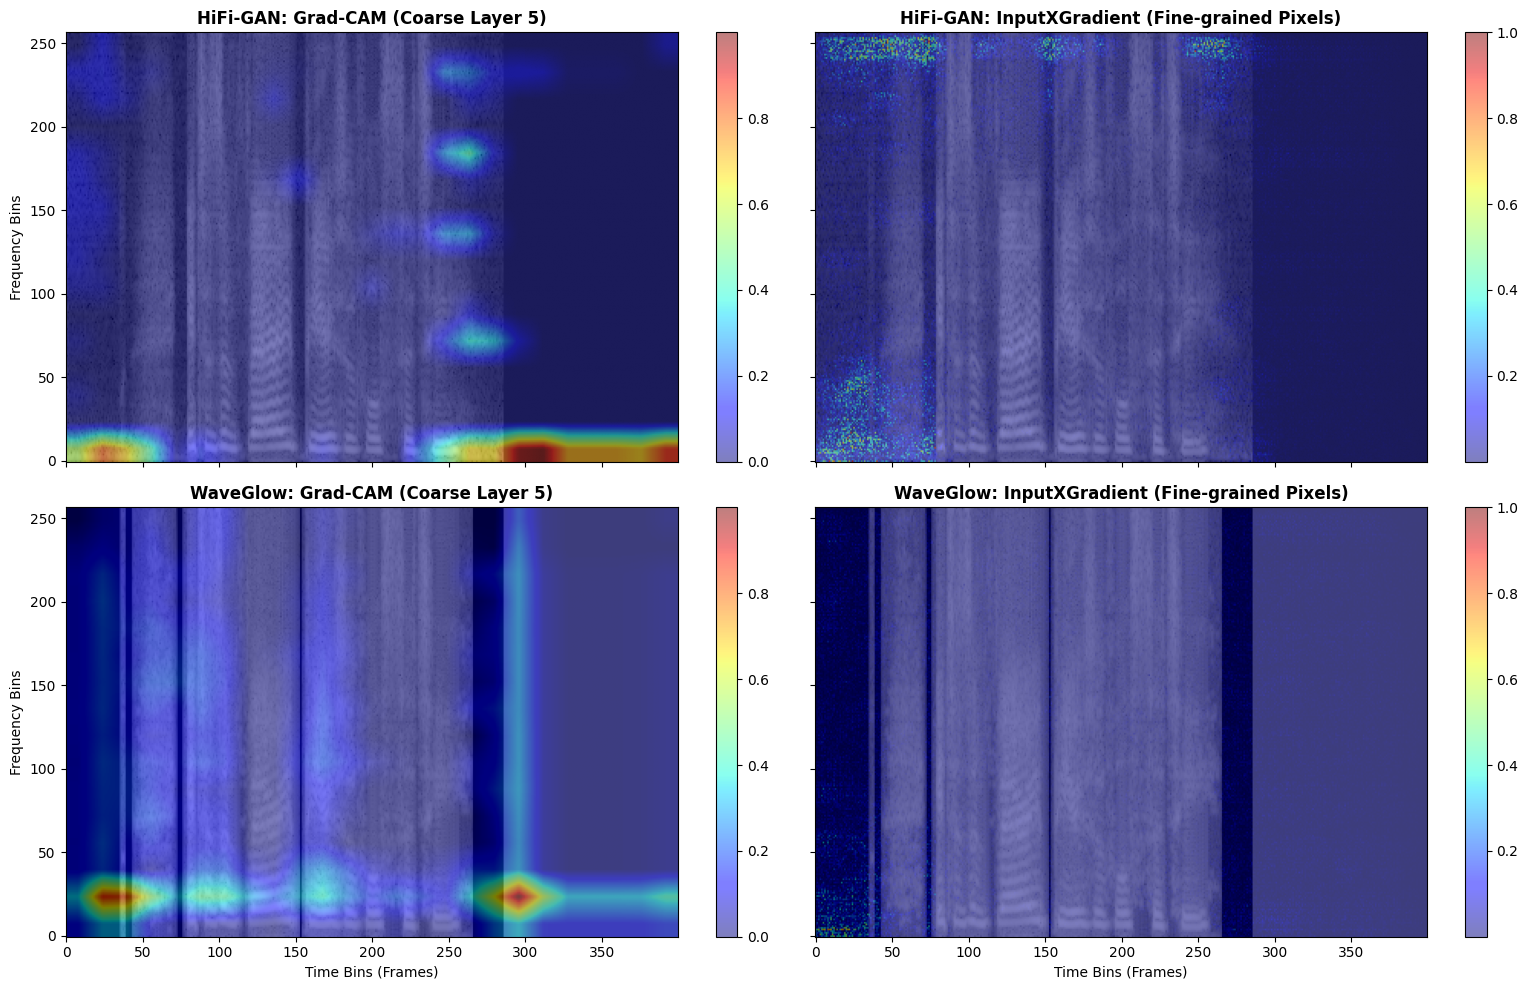

In [56]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from captum.attr import InputXGradient

# 1. Инициализируем метод InputXGradient из библиотеки Captum
input_x_gradient = InputXGradient(model)

def get_input_x_grad_mask(spec_tensor):
    model.eval()
    input_tensor = spec_tensor.to(device).clone()
    input_tensor.requires_grad = True

    # Вычисляем аттрибуцию для класса 0 (Spoof / Дипфейк)
    # Метод возвращает тензор той же размерности, что и вход: [1, 1, 257, 400]
    attribution = input_x_gradient.attribute(input_tensor, target=0)

    # Убираем размерности батча/канала и переводим в numpy
    attr_np = attribution.squeeze().detach().cpu().numpy()

    # Традиционно для визуализации берут абсолютное значение или сумму по каналам,
    # чтобы показать силу влияния (амплитуду важности) каждого пикселя
    attr_np = np.abs(attr_np)

    # Нормализуем маску от 0 до 1 для честного сравнения с Grad-CAM
    if attr_np.max() > 0:
        attr_np = attr_np / attr_np.max()

    return attr_np

# Рассчитываем карты важности InputXGradient для обоих вокодеров
ixg_hifi = get_input_x_grad_mask(hifigan_spec_tensor)
ixg_wave = get_input_x_grad_mask(waveglow_spec_tensor)

# 2. Отрисовка сравнительной матрицы графиков (2 ряда, 2 колонки)
# Ряд 1: Сравнение Grad-CAM и InputXGradient для HiFi-GAN
# Ряд 2: Сравнение Grad-CAM и InputXGradient для WaveGlow
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)

# Извлекаем фоны спектрограмм
bg_hifi = hifigan_spec_tensor.squeeze().cpu().numpy()
bg_wave = waveglow_spec_tensor.squeeze().cpu().numpy()

# --- HiFi-GAN ---
# Grad-CAM (берем cam_mask_hifi из прошлого шага)
axes[0, 0].imshow(bg_hifi, aspect='auto', origin='lower', cmap='gray')
im1 = axes[0, 0].imshow(cam_mask_hifi, aspect='auto', origin='lower', cmap='jet', alpha=0.5)
axes[0, 0].set_title("HiFi-GAN: Grad-CAM (Coarse Layer 5)", fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel("Frequency Bins")
fig.colorbar(im1, ax=axes[0, 0])

# InputXGradient
axes[0, 1].imshow(bg_hifi, aspect='auto', origin='lower', cmap='gray')
im2 = axes[0, 1].imshow(ixg_hifi, aspect='auto', origin='lower', cmap='jet', alpha=0.5)
axes[0, 1].set_title("HiFi-GAN: InputXGradient (Fine-grained Pixels)", fontsize=12, fontweight='bold')
fig.colorbar(im2, ax=axes[0, 1])

# --- WaveGlow ---
# Grad-CAM (берем cam_mask_wave из прошлого шага)
axes[1, 0].imshow(bg_wave, aspect='auto', origin='lower', cmap='gray')
im3 = axes[1, 0].imshow(cam_mask_wave, aspect='auto', origin='lower', cmap='jet', alpha=0.5)
axes[1, 0].set_title("WaveGlow: Grad-CAM (Coarse Layer 5)", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Time Bins (Frames)")
axes[1, 0].set_ylabel("Frequency Bins")
fig.colorbar(im3, ax=axes[1, 0])

# InputXGradient
axes[1, 1].imshow(bg_wave, aspect='auto', origin='lower', cmap='gray')
im4 = axes[1, 1].imshow(ixg_wave, aspect='auto', origin='lower', cmap='jet', alpha=0.5)
axes[1, 1].set_title("WaveGlow: InputXGradient (Fine-grained Pixels)", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Time Bins (Frames)")
fig.colorbar(im4, ax=axes[1, 1])

plt.tight_layout()
plt.show()


Do three plots: mask vs grad-cam vs inputXgradient. Compare them. Does any of the XAI methods align with the mask?

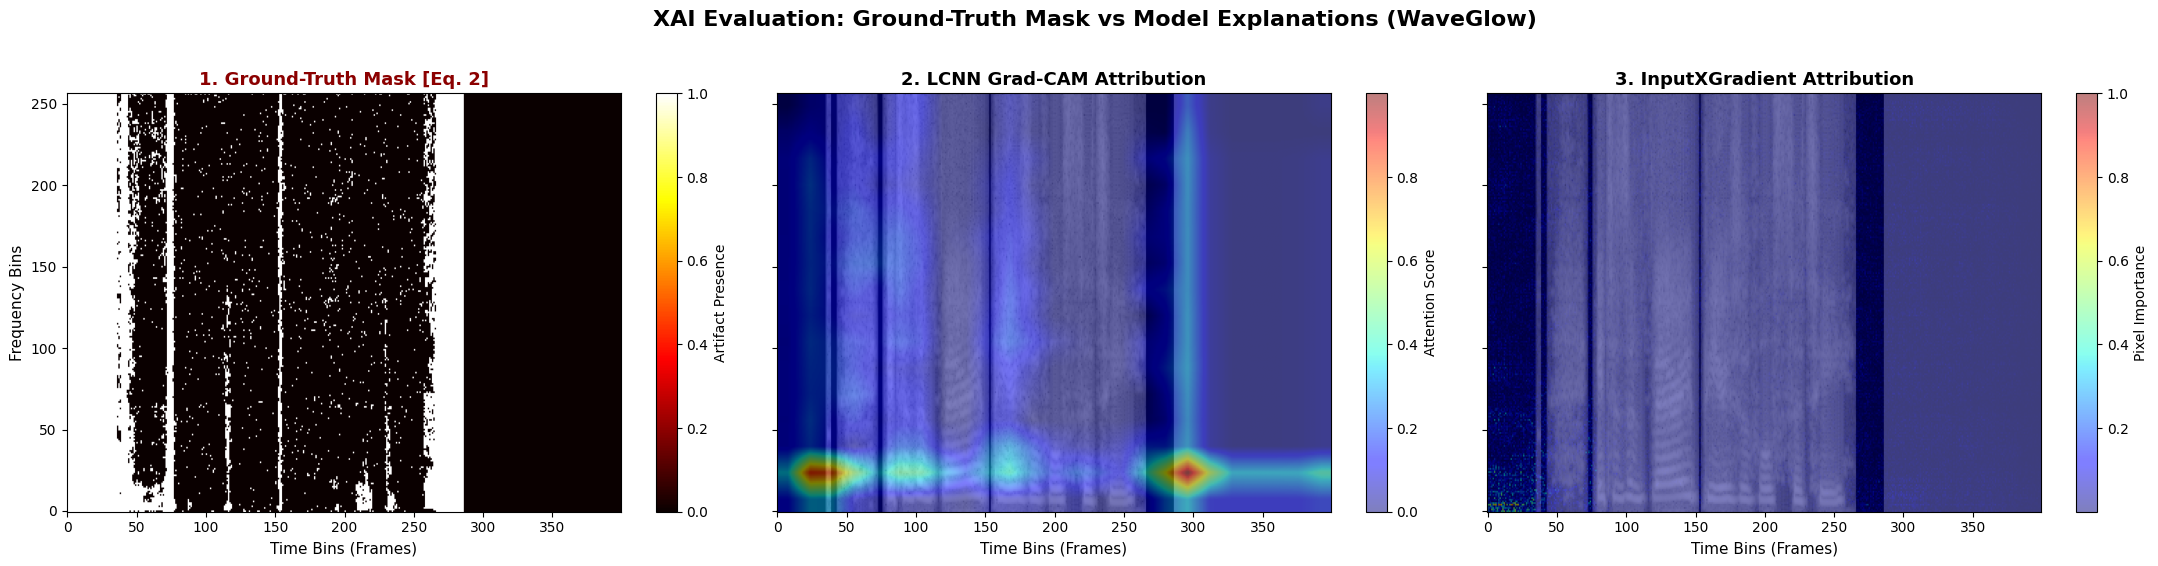

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# Извлекаем фон спектрограммы WaveGlow
bg_wave = waveglow_spec_tensor.squeeze().cpu().numpy()

# 1. Готовим бинарную маску Eq. 2 (используем порог 2.5, как ранее)
real_np = real_spec_tensor.squeeze().cpu().numpy()
delta = np.abs(real_np - bg_wave)
binary_mask = np.where(delta > 2.5, 1.0, 0.0)

# 2. Построение сетки из 3 графиков в один ряд
fig, axes = plt.subplots(1, 3, figsize=(22, 5.5), sharex=True, sharey=True)

# График 1: Истинная маска аномалий вокодера (Ground-Truth)
im1 = axes[0].imshow(binary_mask, aspect='auto', origin='lower', cmap='hot')
axes[0].set_title("1. Ground-Truth Mask [Eq. 2]", fontsize=13, fontweight='bold', color='darkred')
axes[0].set_ylabel("Frequency Bins", fontsize=11)
axes[0].set_xlabel("Time Bins (Frames)", fontsize=11)
fig.colorbar(im1, ax=axes[0], label="Artifact Presence")

# График 2: Объяснение Grad-CAM (Крупные абстрактные слои)
axes[1].imshow(bg_wave, aspect='auto', origin='lower', cmap='gray')
im2 = axes[1].imshow(cam_mask_wave, aspect='auto', origin='lower', cmap='jet', alpha=0.5)
axes[1].set_title("2. LCNN Grad-CAM Attribution", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Time Bins (Frames)", fontsize=11)
fig.colorbar(im2, ax=axes[1], label="Attention Score")

# График 3: Объяснение InputXGradient (Пиксельный уровень)
axes[2].imshow(bg_wave, aspect='auto', origin='lower', cmap='gray')
im3 = axes[2].imshow(ixg_wave, aspect='auto', origin='lower', cmap='jet', alpha=0.5)
axes[2].set_title("3. InputXGradient Attribution", fontsize=13, fontweight='bold')
axes[2].set_xlabel("Time Bins (Frames)", fontsize=11)
fig.colorbar(im3, ax=axes[2], label="Pixel Importance")

plt.suptitle("XAI Evaluation: Ground-Truth Mask vs Model Explanations (WaveGlow)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Your answer here**

Due to skewed distribution for some XAI tools, you may want to look at top-5% points, similarly to the ground-truth mask. Binarize attributions using their $95\%$ quantile and plot again:

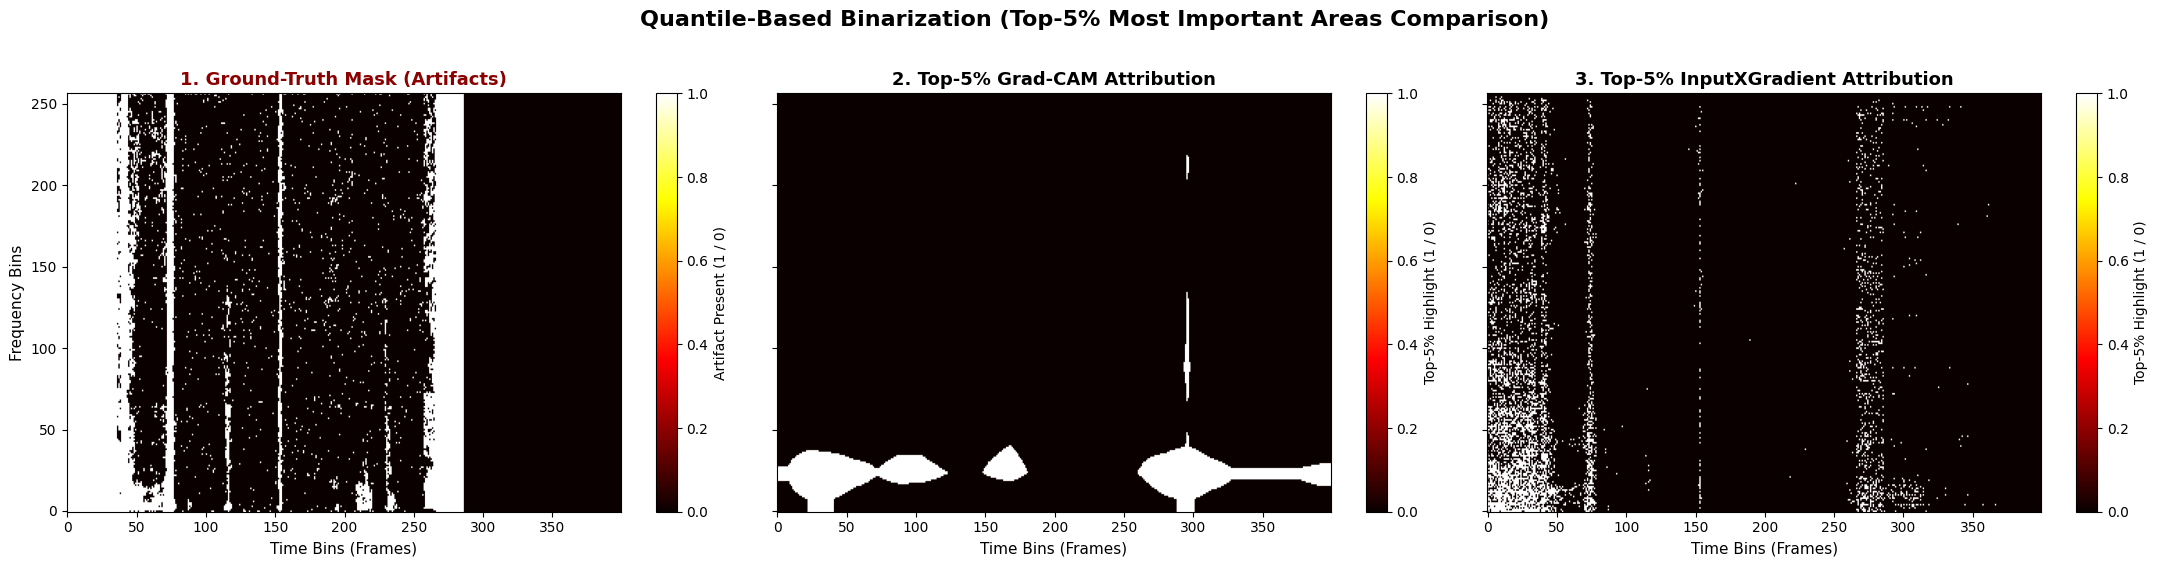

In [59]:
import numpy as np
import matplotlib.pyplot as plt

# Извлекаем фон спектрограммы WaveGlow
bg_wave = waveglow_spec_tensor.squeeze().cpu().numpy()

# 1. Бинарная маска Ground-Truth (Eq. 2) на основе порога разности энергии
real_np = real_spec_tensor.squeeze().cpu().numpy()
delta = np.abs(real_np - bg_wave)
binary_mask = np.where(delta > 2.5, 1.0, 0.0)

# 2. Бинаризация Grad-CAM по 95% квантилю (выделяем топ-5% точек важности)
q_gradcam = np.quantile(cam_mask_wave, 0.95)
binary_gradcam = np.where(cam_mask_wave >= q_gradcam, 1.0, 0.0)

# 3. Бинаризация InputXGradient по 95% квантилю (выделяем топ-5% пикселей)
q_ixg = np.quantile(ixg_wave, 0.95)
binary_ixg = np.where(ixg_wave >= q_ixg, 1.0, 0.0)

# =====================================================================
# Отрисовка трех бинарных графиков в один ряд
# =====================================================================
fig, axes = plt.subplots(1, 3, figsize=(22, 5.5), sharex=True, sharey=True)

# График 1: Истинная маска дефектов
im1 = axes[0].imshow(binary_mask, aspect='auto', origin='lower', cmap='hot')
axes[0].set_title("1. Ground-Truth Mask (Artifacts)", fontsize=13, fontweight='bold', color='darkred')
axes[0].set_ylabel("Frequency Bins", fontsize=11)
axes[0].set_xlabel("Time Bins (Frames)", fontsize=11)
fig.colorbar(im1, ax=axes[0], label="Artifact Present (1 / 0)")

# График 2: Бинаризованный Grad-CAM (Топ-5% фокуса модели)
im2 = axes[1].imshow(binary_gradcam, aspect='auto', origin='lower', cmap='hot')
axes[1].set_title("2. Top-5% Grad-CAM Attribution", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Time Bins (Frames)", fontsize=11)
fig.colorbar(im2, ax=axes[1], label="Top-5% Highlight (1 / 0)")

# График 3: Бинаризованный InputXGradient (Топ-5% пикселей)
im3 = axes[2].imshow(binary_ixg, aspect='auto', origin='lower', cmap='hot')
axes[2].set_title("3. Top-5% InputXGradient Attribution", fontsize=13, fontweight='bold')
axes[2].set_xlabel("Time Bins (Frames)", fontsize=11)
fig.colorbar(im3, ax=axes[2], label="Top-5% Highlight (1 / 0)")

plt.suptitle("Quantile-Based Binarization (Top-5% Most Important Areas Comparison)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


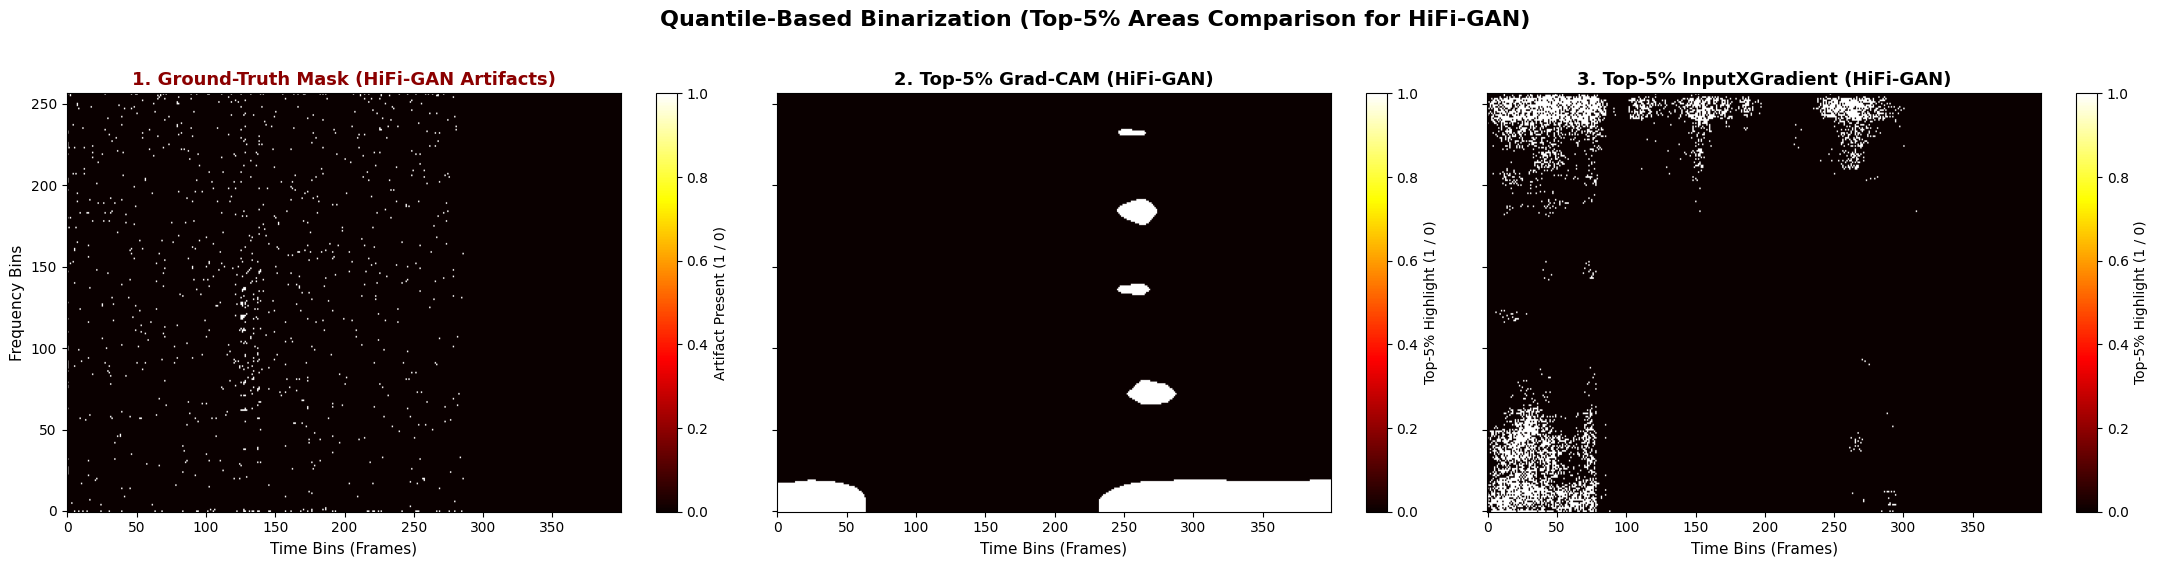

In [60]:
import numpy as np
import matplotlib.pyplot as plt

# Извлекаем фон спектрограммы HiFi-GAN
bg_hifi = hifigan_spec_tensor.squeeze().cpu().numpy()

# 1. Бинарная маска Ground-Truth (Eq. 2) для HiFi-GAN (порог 2.5)
real_np = real_spec_tensor.squeeze().cpu().numpy()
delta_hifi = np.abs(real_np - bg_hifi)
binary_mask_hifi = np.where(delta_hifi > 2.5, 1.0, 0.0)

# 2. Бинаризация Grad-CAM по 95% квантилю (топ-5% фокуса для HiFi-GAN)
q_gradcam_hifi = np.quantile(cam_mask_hifi, 0.95)
binary_gradcam_hifi = np.where(cam_mask_hifi >= q_gradcam_hifi, 1.0, 0.0)

# 3. Biнаризация InputXGradient по 95% квантилю (топ-5% пикселей для HiFi-GAN)
q_ixg_hifi = np.quantile(ixg_hifi, 0.95)
binary_ixg_hifi = np.where(ixg_hifi >= q_ixg_hifi, 1.0, 0.0)

# =====================================================================
# Отрисовка трех бинарных графиков в один ряд
# =====================================================================
fig, axes = plt.subplots(1, 3, figsize=(22, 5.5), sharex=True, sharey=True)

# График 1: Истинная маска дефектов HiFi-GAN
im1 = axes[0].imshow(binary_mask_hifi, aspect='auto', origin='lower', cmap='hot')
axes[0].set_title("1. Ground-Truth Mask (HiFi-GAN Artifacts)", fontsize=13, fontweight='bold', color='darkred')
axes[0].set_ylabel("Frequency Bins", fontsize=11)
axes[0].set_xlabel("Time Bins (Frames)", fontsize=11)
fig.colorbar(im1, ax=axes[0], label="Artifact Present (1 / 0)")

# График 2: Бинаризованный Grad-CAM
im2 = axes[1].imshow(binary_gradcam_hifi, aspect='auto', origin='lower', cmap='hot')
axes[1].set_title("2. Top-5% Grad-CAM (HiFi-GAN)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Time Bins (Frames)", fontsize=11)
fig.colorbar(im2, ax=axes[1], label="Top-5% Highlight (1 / 0)")

# График 3: Бинаризованный InputXGradient
im3 = axes[2].imshow(binary_ixg_hifi, aspect='auto', origin='lower', cmap='hot')
axes[2].set_title("3. Top-5% InputXGradient (HiFi-GAN)", fontsize=13, fontweight='bold')
axes[2].set_xlabel("Time Bins (Frames)", fontsize=11)
fig.colorbar(im3, ax=axes[2], label="Top-5% Highlight (1 / 0)")

plt.suptitle("Quantile-Based Binarization (Top-5% Areas Comparison for HiFi-GAN)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Your analysis here**